In [32]:
import pandas as pd
from pathlib import Path
from sklearn import metrics
from sklearn.cluster import KMeans
from kneed import KneeLocator
import matplotlib.pyplot as plt

In [33]:
data_dir = Path("data")
INDIR = Path("data/data_processed")
OUTDIR = Path("data/data_model")

OUTDIR.mkdir(parents=True, exist_ok=True)

In [34]:
arquivo = INDIR / "ANALISE_NOTAS_ENEM_MUNICIPIOS_SP_MODELO.csv"
X_scaled = pd.read_csv(arquivo, encoding='utf-8')

In [35]:
X_scaled.head()

,NU_NOTA_CN_MEDIA,NU_NOTA_CH_MEDIA,NU_NOTA_LC_MEDIA,NU_NOTA_MT_MEDIA,NU_NOTA_REDACAO_MEDIA,RENDA_FAMILIAR_SM_LOG_MEDIANA,REGIAO_GRANDE_SP,REGIAO_INTERIOR,REGIAO_LITORAL
0,1.022390,1.396181,1.042146,1.283894,0.920630,0.029932,0,1,0
1,0.645105,0.251115,0.302612,0.606230,0.723615,1.275477,0,1,0
2,1.564521,1.649462,1.412722,1.570834,1.234435,2.354417,0,1,0
3,1.394066,1.183277,1.205768,1.491113,0.617502,1.275477,0,1,0
4,-0.547368,-0.977093,-0.835371,-0.230580,-0.123298,0.029932,0,1,0


In [36]:
k_range = range(2, 11)
inertia_values = []

for k in k_range:
    model = KMeans(
        n_clusters=k,
        n_init=100,
        random_state=0,
        max_iter=200
    )
    
    model.fit(X_scaled)
    inertia_values.append(model.inertia_)

df_inertia = pd.DataFrame({
    'k': k_range,
    'inertia': inertia_values
}).set_index('k')

knee = KneeLocator(
    x=df_inertia.index,
    y=df_inertia['inertia'],
    curve='convex',
    direction='decreasing'
)

k_elbow = knee.knee

if k_elbow is None:
    print('Elbow não encontrado')
else:
    print(f'Elbow encontrado em k={k_elbow}')

Elbow encontrado em k=4


In [37]:
df_inertia.round(2)

,inertia
k,
2,653.24
3,456.22
4,380.02
5,340.29
6,302.10
7,272.29
8,249.20
9,227.88
10,211.26


In [38]:
k_range = range(2, 11)

ch_values = []

for k in k_range:
    model = KMeans(
        n_clusters=k,
        n_init=100,
        random_state=0,
        max_iter=200
    )
    
    labels = model.fit_predict(X_scaled)
    score = metrics.calinski_harabasz_score(X_scaled, labels)
    ch_values.append(score)

df_ch = pd.DataFrame({
    'k': k_range,
    'calinski_harabasz': ch_values
}).set_index('k')

k_ch = df_ch['calinski_harabasz'].idxmax()
print(f"Melhor valor de k (Calinski-Harabasz): {k_ch}")

Melhor valor de k (Calinski-Harabasz): 2


In [39]:
df_ch.round(2)

,calinski_harabasz
k,
2,218.22
3,200.18
4,173.21
5,150.35
6,139.98
7,132.50
8,126.15
9,122.46
10,118.58


In [40]:
k_range = range(2, 11)
db_values = []

for k in k_range:
    model = KMeans(
        n_clusters=k,
        n_init=100,
        random_state=0,
        max_iter=200
    )
    
    labels = model.fit_predict(X_scaled)
    score = metrics.davies_bouldin_score(X_scaled, labels)
    db_values.append(score)

df_db = pd.DataFrame({
    'k': k_range,
    'davies_bouldin': db_values
}).set_index('k')

k_db = df_db['davies_bouldin'].idxmin()
print(f"Melhor valor de k (Davies-Bouldin): {k_db}")

Melhor valor de k (Davies-Bouldin): 2


In [41]:
df_db.round(2)

,davies_bouldin
k,
2,0.91
3,1.01
4,1.15
5,1.21
6,1.17
7,1.20
8,1.16
9,1.17
10,1.13


In [42]:
k_range = range(2, 11)
silhouette_values = []

for k in k_range:
    model = KMeans(
        n_clusters=k,
        n_init=100,
        random_state=0,
        max_iter=200
    )
    
    labels = model.fit_predict(X_scaled)

    score = metrics.silhouette_score(
        X_scaled,
        labels,
        sample_size=5000,
        random_state=0
    )
    
    silhouette_values.append(score)

df_silhouette = pd.DataFrame({
    'k': k_range,
    'silhouette': silhouette_values
}).set_index('k')

k_sil = df_silhouette['silhouette'].idxmax()
k_sil

2

In [43]:
df_silhouette

,silhouette
k,
2,0.404984
3,0.335425
4,0.276840
5,0.275632
6,0.277626
7,0.265453
8,0.267297
9,0.270903
10,0.279997


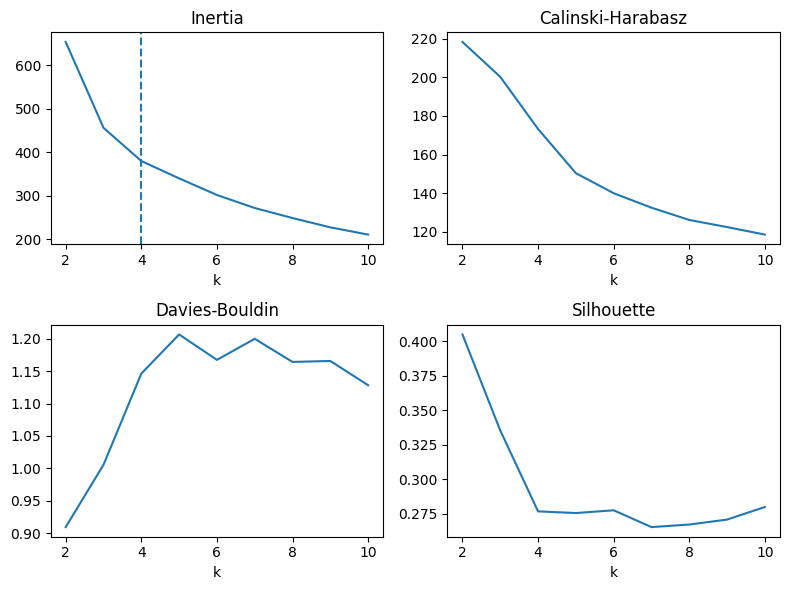

In [44]:
fig, axes = plt.subplots(2, 2, figsize=(8, 6))


df_inertia['inertia'].plot(ax=axes[0, 0], title='Inertia')

if k_elbow is not None:
    axes[0, 0].axvline(k_elbow, linestyle='--')


df_ch['calinski_harabasz'].plot(ax=axes[0, 1], title='Calinski-Harabasz')

df_db['davies_bouldin'].plot(ax=axes[1, 0], title='Davies-Bouldin')

df_silhouette['silhouette'].plot(ax=axes[1, 1], title='Silhouette')

plt.tight_layout()